In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

In [4]:
supp_chain= pd.read_csv(r'C:/Users/arunt/Desktop/Projects/Supply Chain Optimization/archived/DataCoSupplyChainDataset.csv',encoding='latin1')

In [5]:
blank_counts=supp_chain.isnull().sum()
print(blank_counts[blank_counts>0])
supp_chain.shape

Customer Lname      8
Customer Zipcode    3
dtype: int64


(180519, 51)

In [6]:
for i in supp_chain.columns:
   x=supp_chain[i].nunique()
   print(supp_chain[i].name,':', x)

Type : 4
Days for shipping (real) : 7
Days for shipment (scheduled) : 4
Benefit per order : 21998
Sales per customer : 2927
Delivery Status : 4
Late_delivery_risk : 2
Category Id : 51
Category Name : 50
Customer City : 563
Customer Country : 2
Customer Email : 1
Customer Fname : 782
Customer Id : 20652
Customer Lname : 1109
Customer Password : 1
Customer Segment : 3
Customer State : 46
Customer Street : 7458
Customer Zipcode : 995
Department Id : 11
Department Name : 11
Latitude : 11250
Longitude : 4487
Market : 5
Order City : 3597
Order Country : 164
Order Customer Id : 20652
order date (DateOrders) : 65752
Order Id : 65752
Order Item Cardprod Id : 118
Order Item Discount : 1017
Order Item Discount Rate : 18
Order Item Id : 180519
Order Item Product Price : 75
Order Item Profit Ratio : 162
Order Item Quantity : 5
Sales : 193
Order Item Total : 2927
Order Profit Per Order : 21998
Order Region : 23
Order State : 1089
Order Status : 9
Product Card Id : 118
Product Category Id : 51
Produc

In [7]:

supp_chain.columns=(supp_chain.columns
                     .str.lower()
                     .str.strip()
                     .str.replace(" ","_")
                     .str.replace("-","_"))

supp_chain.columns


Index(['type', 'days_for_shipping_(real)', 'days_for_shipment_(scheduled)',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_email', 'customer_fname', 'customer_id',
       'customer_lname', 'customer_password', 'customer_segment',
       'customer_state', 'customer_street', 'customer_zipcode',
       'department_id', 'department_name', 'latitude', 'longitude', 'market',
       'order_city', 'order_country', 'order_customer_id',
       'order_date_(dateorders)', 'order_id', 'order_item_cardprod_id',
       'order_item_discount', 'order_item_discount_rate', 'order_item_id',
       'order_item_product_price', 'order_item_profit_ratio',
       'order_item_quantity', 'sales', 'order_item_total',
       'order_profit_per_order', 'order_region', 'order_state', 'order_status',
       'product_card_id', 'product_category_id', 'product_image',
       'product_na

In [8]:

supp_chain["order_item_profit_ratio"]

0         0.29
1        -0.80
2        -0.80
3         0.08
4         0.45
          ... 
180514    0.10
180515   -1.55
180516    0.36
180517    0.48
180518    0.44
Name: order_item_profit_ratio, Length: 180519, dtype: float64

In [9]:
supp_chain['order_date_(dateorders)']=pd.to_datetime(supp_chain['order_date_(dateorders)'],format='mixed')
supp_chain['shipping_date_(dateorders)']=pd.to_datetime(supp_chain['shipping_date_(dateorders)'],format='mixed')


In [10]:
numeric_column = [
    
   'benefit_per_order',
    'sales_per_customer',
    'sales',
    'order_item_quantity',
    'order_profit_per_order',
    'product_price',
    'latitude',
    'longitude'
]


for col in numeric_column:
    supp_chain[col] = pd.to_numeric(supp_chain[col], errors="coerce")


In [11]:
supp_chain["profit_margin"]=(
  supp_chain["order_profit_per_order"]/supp_chain["sales"]
)*100

supp_chain["delivery_delay"] = (
    supp_chain["days_for_shipping_(real)"] -supp_chain["days_for_shipment_(scheduled)"]
)

In [12]:
supp_chain["shipping_performance"]=np.where(
  supp_chain["delivery_delay"]>0,
  "Delayed",
  "On-Time"
)
supp_chain["shipping_performance"]

0         On-Time
1         Delayed
2         On-Time
3         On-Time
4         On-Time
           ...   
180514    On-Time
180515    Delayed
180516    Delayed
180517    On-Time
180518    On-Time
Name: shipping_performance, Length: 180519, dtype: object

In [13]:
customers = supp_chain[
[
'customer_id',
'customer_fname',
'customer_lname',
'customer_segment',
'customer_city',
'customer_state',
'customer_country'
]
].drop_duplicates()

product = supp_chain[
[
'product_card_id',
'product_name',
'category_name',
'department_name',
'product_price'
]
].drop_duplicates()

orders = supp_chain[
[
'order_item_id',
'order_date_(dateorders)',
'order_customer_id',
'product_card_id',
'order_id',
'sales',
'order_profit_per_order',
'order_item_quantity',
'shipping_mode',
'delivery_status',
'late_delivery_risk',
'order_item_discount_rate',
'order_region'
]
].copy()

shipping = supp_chain[
[
'order_item_id',
'shipping_date_(dateorders)',
'days_for_shipping_(real)',
'days_for_shipment_(scheduled)',
'delivery_delay',
'shipping_performance'
]
]



In [14]:
master = orders.merge(
    customers,
    left_on="order_customer_id",
    right_on="customer_id",
    how="left"
)
master = master.merge(
    product,
    on="product_card_id",
    how="left"
)
master = master.merge(
    shipping,
    on="order_item_id",
    how="left"
)
master.to_csv(
    "dataco_master.csv",
   
)

In [15]:
print(customers.shape)
print(product.shape)
print(orders.shape)
print(shipping.shape)
print(master.shape)

(20652, 7)
(118, 5)
(180519, 13)
(180519, 6)
(180519, 29)


In [16]:
master.columns

Index(['order_item_id', 'order_date_(dateorders)', 'order_customer_id',
       'product_card_id', 'order_id', 'sales', 'order_profit_per_order',
       'order_item_quantity', 'shipping_mode', 'delivery_status',
       'late_delivery_risk', 'order_item_discount_rate', 'order_region',
       'customer_id', 'customer_fname', 'customer_lname', 'customer_segment',
       'customer_city', 'customer_state', 'customer_country', 'product_name',
       'category_name', 'department_name', 'product_price',
       'shipping_date_(dateorders)', 'days_for_shipping_(real)',
       'days_for_shipment_(scheduled)', 'delivery_delay',
       'shipping_performance'],
      dtype='object')

In [17]:
master["order_year"]=master["order_date_(dateorders)"].dt.year
master["order_month"]=master["order_date_(dateorders)"].dt.month_name()
master["order_quarter"]=master["order_date_(dateorders)"].dt.quarter
master

,order_item_id,order_date_(dateorders),order_customer_id,product_card_id,order_id,sales,order_profit_per_order,order_item_quantity,shipping_mode,delivery_status,...,department_name,product_price,shipping_date_(dateorders),days_for_shipping_(real),days_for_shipment_(scheduled),delivery_delay,shipping_performance,order_year,order_month,order_quarter
0,180517,2018-01-31 22:56:00,20755,1360,77202,327.750000,91.250000,1,Standard Class,Advance shipping,...,Fitness,327.750000,2018-02-03 22:56:00,3,4,-1,On-Time,2018,January,1
1,179254,2018-01-13 12:27:00,19492,1360,75939,327.750000,-249.089996,1,Standard Class,Late delivery,...,Fitness,327.750000,2018-01-18 12:27:00,5,4,1,Delayed,2018,January,1
2,179253,2018-01-13 12:06:00,19491,1360,75938,327.750000,-247.779999,1,Standard Class,Shipping on time,...,Fitness,327.750000,2018-01-17 12:06:00,4,4,0,On-Time,2018,January,1
3,179252,2018-01-13 11:45:00,19490,1360,75937,327.750000,22.860001,1,Standard Class,Advance shipping,...,Fitness,327.750000,2018-01-16 11:45:00,3,4,-1,On-Time,2018,January,1
4,179251,2018-01-13 11:24:00,19489,1360,75936,327.750000,134.210007,1,Standard Class,Advance shipping,...,Fitness,327.750000,2018-01-15 11:24:00,2,4,-2,On-Time,2018,January,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,65177,2016-01-16 03:40:00,1005,1004,26043,399.980011,40.000000,1,Standard Class,Shipping on time,...,Fan Shop,399.980011,2016-01-20 03:40:00,4,4,0,On-Time,2016,January,1
180515,65161,2016-01-16 01:34:00,9141,1004,26037,399.980011,-613.770019,1,Second Class,Late delivery,...,Fan Shop,399.980011,2016-01-19 01:34:00,3,2,1,Delayed,2016,January,1
180516,65129,2016-01-15 21:00:00,291,1004,26024,399.980011,141.110001,1,Standard Class,Late delivery,...,Fan Shop,399.980011,2016-01-20 21:00:00,5,4,1,Delayed,2016,January,1
180517,65126,2016-01-15 20:18:00,2813,1004,26022,399.980011,186.229996,1,Standard Class,Advance shipping,...,Fan Shop,399.980011,2016-01-18 20:18:00,3,4,-1,On-Time,2016,January,1


In [18]:
master["order_value_segment"]=pd.cut(
  master["sales"],
  bins=[0,100,500,np.inf],
  labels=["Low","Medium","High"]
)

In [19]:
master["unit_profit"]=np.where(
  master["order_item_quantity"]>0,
  master["order_profit_per_order"]/master["order_item_quantity"],
  np.nan
)

In [20]:
master["avg_selling_price"]=np.where(
  master["order_item_quantity"]>0,
  master["sales"]/master["order_item_quantity"],
  np.nan
)
master["profit_margin"]=np.where(
  master["sales"]>0,
  (master["order_profit_per_order"]/master["sales"])*100,
  np.nan
)

In [21]:
master

,order_item_id,order_date_(dateorders),order_customer_id,product_card_id,order_id,sales,order_profit_per_order,order_item_quantity,shipping_mode,delivery_status,...,days_for_shipment_(scheduled),delivery_delay,shipping_performance,order_year,order_month,order_quarter,order_value_segment,unit_profit,avg_selling_price,profit_margin
0,180517,2018-01-31 22:56:00,20755,1360,77202,327.750000,91.250000,1,Standard Class,Advance shipping,...,4,-1,On-Time,2018,January,1,Medium,91.250000,327.750000,27.841342
1,179254,2018-01-13 12:27:00,19492,1360,75939,327.750000,-249.089996,1,Standard Class,Late delivery,...,4,1,Delayed,2018,January,1,Medium,-249.089996,327.750000,-75.999999
2,179253,2018-01-13 12:06:00,19491,1360,75938,327.750000,-247.779999,1,Standard Class,Shipping on time,...,4,0,On-Time,2018,January,1,Medium,-247.779999,327.750000,-75.600305
3,179252,2018-01-13 11:45:00,19490,1360,75937,327.750000,22.860001,1,Standard Class,Advance shipping,...,4,-1,On-Time,2018,January,1,Medium,22.860001,327.750000,6.974829
4,179251,2018-01-13 11:24:00,19489,1360,75936,327.750000,134.210007,1,Standard Class,Advance shipping,...,4,-2,On-Time,2018,January,1,Medium,134.210007,327.750000,40.948896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,65177,2016-01-16 03:40:00,1005,1004,26043,399.980011,40.000000,1,Standard Class,Shipping on time,...,4,0,On-Time,2016,January,1,Medium,40.000000,399.980011,10.000500
180515,65161,2016-01-16 01:34:00,9141,1004,26037,399.980011,-613.770019,1,Second Class,Late delivery,...,2,1,Delayed,2016,January,1,Medium,-613.770019,399.980011,-153.450173
180516,65129,2016-01-15 21:00:00,291,1004,26024,399.980011,141.110001,1,Standard Class,Late delivery,...,4,1,Delayed,2016,January,1,Medium,141.110001,399.980011,35.279263
180517,65126,2016-01-15 20:18:00,2813,1004,26022,399.980011,186.229996,1,Standard Class,Advance shipping,...,4,-1,On-Time,2016,January,1,Medium,186.229996,399.980011,46.559826


In [22]:
regional_revenue=master.groupby('order_region')['sales'].sum().sort_values(ascending=False)

category_revenue=master.groupby('category_name')['order_profit_per_order'].sum().sort_values()

monthly_revenue= master.pivot_table(
    values='sales',       
    index='order_month',  
    columns='order_year',
    aggfunc='sum'        
)

ship_per=master.groupby('shipping_mode')['delivery_delay'].mean()

segment_revenue=master.groupby('customer_segment')['sales'].sum()

top_products=master.groupby('product_name')['sales'].sum().nlargest(10)

country_revenue=master.groupby('customer_country')['sales'].sum()

profit_by_region=master.groupby('order_region')['order_profit_per_order'].sum()

profit_by_state=master.groupby('customer_state')['order_profit_per_order'].sum()

profit_by_category=master.groupby('customer_segment')['order_profit_per_order'].sum()

top_products
ship_per
regional_revenue
monthly_revenue


order_year,2015,2016,2017,2018
order_month,,,,
April,1.014463e+06,1.001212e+06,1.038322e+06,NaN
August,1.029495e+06,1.048200e+06,1.109337e+06,NaN
December,1.057841e+06,1.037408e+06,5.039108e+05,NaN
February,9.270099e+05,9.685428e+05,9.925349e+05,NaN
January,1.051590e+06,1.046308e+06,1.029698e+06,331650.115157
July,1.038081e+06,1.045716e+06,1.104373e+06,NaN
June,1.024006e+06,1.003060e+06,1.032086e+06,NaN
March,1.051254e+06,1.025853e+06,1.048005e+06,NaN
May,1.050478e+06,1.029400e+06,1.105485e+06,NaN


In [23]:
profit_by_category

customer_segment
Consumer       2.073488e+06
Corporate      1.202575e+06
Home Office    6.908403e+05
Name: order_profit_per_order, dtype: float64

In [24]:
latest_date = master["order_date_(dateorders)"].max() + pd.Timedelta(days=1)

rfm = master.groupby("order_customer_id").agg({
    "order_date_(dateorders)": lambda x: (latest_date - x.max()).days,
    "order_id": "nunique",
    "sales": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

In [25]:

rfm["R"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])


rfm["RFM_Score"] = (
    rfm["R"].astype(str) +
    rfm["F"].astype(str) +
    rfm["M"].astype(str)
)



rfm[["R", "F", "M", "RFM_Score"]]

,R,F,M,RFM_Score
order_customer_id,,,,
1,1,1,2,112
2,3,3,3,333
3,2,4,5,245
4,1,3,3,133
5,1,3,3,133
...,...,...,...,...
20753,5,3,1,531
20754,5,3,1,531
20755,5,3,2,532


In [26]:
def segment(row):
    if row["R"] >= 4 and row["F"] >= 4:
        return "Champions"
    elif row["R"] >= 3 and row["F"] >= 3:
        return "Loyal"
    elif row["R"] <= 2 and row["F"] >= 3:
        return "At Risk"
    else:
        return "Others"

rfm["Segment"] = rfm.apply(segment, axis=1)

In [27]:
master["OrderMonth"] = master["order_date_(dateorders)"].dt.to_period("M")
master["CohortMonth"] = (
    master.groupby("order_customer_id")["OrderMonth"]
    .transform("min")
)

In [28]:
master["CohortIndex"] = (
    (master["OrderMonth"] - master["CohortMonth"]).apply(lambda x: x.n)
)

In [29]:

cohort_data = master.groupby(['CohortMonth', 'CohortIndex'])['order_customer_id'].nunique().reset_index()

cohort_table = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='order_customer_id')

cohort_sizes = cohort_table.iloc[:, 0]

retention_table = cohort_table.divide(cohort_sizes, axis=0)



In [30]:
abc =master.groupby("product_name")["sales"].sum().sort_values(ascending=False).reset_index()
abc["RevenuePct"] = abc["sales"] / abc["sales"].sum()
abc["CumPct"] = abc["RevenuePct"].cumsum()

def classify(x):
    if x <= 0.80:
        return "A"
    elif x <= 0.95:
        return "B"
    return "C"

abc["Class"] = abc["CumPct"].apply(classify)

abc


,product_name,sales,RevenuePct,CumPct,Class
0,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,0.188384,0.188384,A
1,Perfect Fitness Perfect Rip Deck,4.421143e+06,0.120190,0.308574,A
2,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,0.111960,0.420534,A
3,Nike Men's Free 5.0+ Running Shoe,3.667633e+06,0.099705,0.520239,A
4,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,0.085574,0.605813,A
...,...,...,...,...,...
113,Bushnell Pro X7 Jolt Slope Rangefinder,6.599890e+03,0.000179,0.999426,C
114,Toys,6.104660e+03,0.000166,0.999592,C
115,Bowflex SelectTech 1090 Dumbbells,5.999900e+03,0.000163,0.999755,C
116,Polar Loop Activity Tracker,5.937300e+03,0.000161,0.999917,C


In [31]:
monthly_sales = (
    master
    .resample("M", on="order_date_(dateorders)")["sales"]
    .sum()
    .reset_index()
)

monthly_sales.columns = ["ds", "y"]





C:\Users\arunt\AppData\Local\Temp\ipykernel_4440\1468043893.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M", on="order_date_(dateorders)")["sales"]


16:54:45 - cmdstanpy - INFO - Chain [1] start processing
16:54:46 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\arunt\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


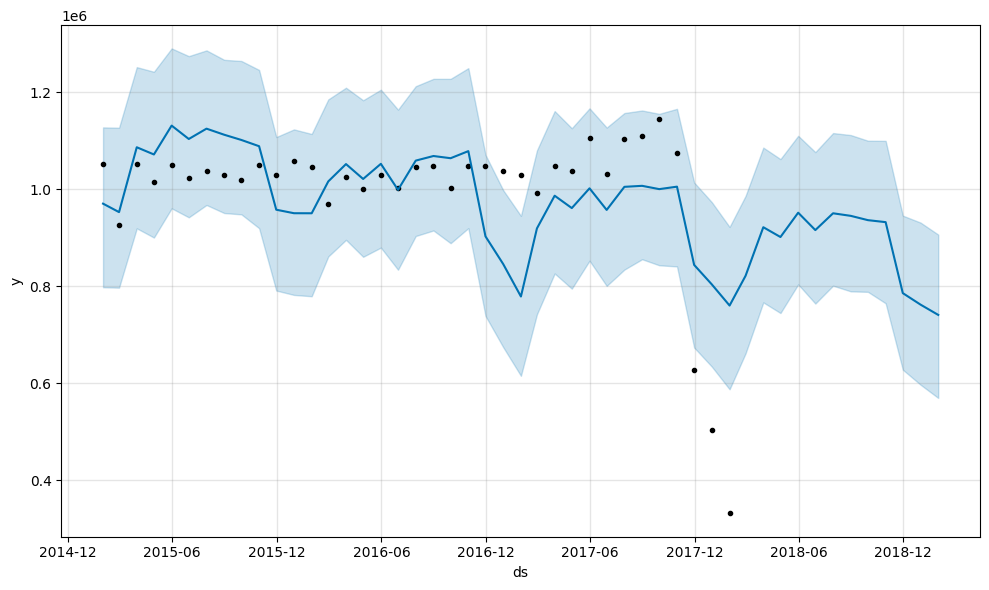

In [32]:
model = Prophet()

model.fit(monthly_sales)

future = model.make_future_dataframe(periods=12, freq="M")

forecast = model.predict(future)

model.plot(forecast)
plt.show()

In [33]:
forecast.to_csv("forecast_demand.csv",index=False)
abc.to_csv("abc.csv",index=False)
retention_long = retention_table.reset_index().melt(
    id_vars="CohortMonth",
    var_name="CohortIndex",
    value_name="RetentionRate"
)
retention_long["CohortIndex"] = retention_long["CohortIndex"].astype(int)
retention_long.to_csv("retention_table.csv", index=False)
rfm.to_csv("rfm.csv",index=True)
master.to_csv("dataco_master.csv")

In [34]:
actual = monthly_sales.rename(columns={"y": "Actual_Sales"})
fc = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].rename(columns={"yhat": "Forecast_Sales"})

forecast_vs_actual = actual.merge(fc, on="ds", how="outer").sort_values("ds")
forecast_vs_actual.to_csv("forecast_vs_actual.csv", index=False)